In [ ]:
# Cloning the repo
!git clone -b feature/cv-yolo-detection https://github.com/Govind-2004/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization.git

Cloning into 'AI_Adaptive_Traffic_Analysis_and_Signal_Optimization'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 72 (delta 23), reused 26 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 1016.64 KiB | 2.75 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [ ]:
%cd AI_Adaptive_Traffic_Analysis_and_Signal_Optimization

/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization


# Environment Set Up

## Install dependencies

In [ ]:
# Install required packages
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.3 MB/s eta 0:00:00


## Import libraries

In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd

In [ ]:
# Importing detector.py
sys.path.append("/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/detection")
import detector

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Verifying if detector.py is working
model, device = detector.load_model()
print("Running on:", device)
print("Vehicle classes:", detector.VEHICLE_CLASSES)

Running on: cuda
Vehicle classes: {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


## Load Test Video

In [ ]:
# Opening the video
video_path = "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

print("Video opened:", cap.isOpened())
print("Frame read successfully:", ret)

if ret:
    print("Frame shape:", frame.shape)

Video opened: True
Frame read successfully: True
Frame shape: (1080, 1920, 3)


# ByteTrack code

In [ ]:
results = model.track(
    source=video_path,
    classes=list(detector.VEHICLE_CLASSES.keys()),
    conf=0.35,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True
)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 277ms
Prepared 1 package in 46ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



In [ ]:
frame_count = 0
for r in results:
    if r.boxes.id is not None:
        for box, track_id in zip(r.boxes, r.boxes.id):
            cls_name = detector.VEHICLE_CLASSES[int(box.cls[0])]
            print(f"Frame {frame_count} — Vehicle ID {int(track_id)} ({cls_name})")
    frame_count += 1
    if frame_count >= 5:
        break


video 1/1 (frame 1/1501) /content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4: 384x640 7 cars, 2 buss, 1 truck, 8.4ms
Frame 0 — Vehicle ID 1 (car)
Frame 0 — Vehicle ID 2 (bus)
Frame 0 — Vehicle ID 3 (car)
Frame 0 — Vehicle ID 4 (car)
Frame 0 — Vehicle ID 5 (car)
Frame 0 — Vehicle ID 6 (car)
Frame 0 — Vehicle ID 7 (car)
Frame 0 — Vehicle ID 8 (bus)
Frame 0 — Vehicle ID 9 (truck)
Frame 0 — Vehicle ID 10 (car)
video 1/1 (frame 2/1501) /content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4: 384x640 7 cars, 1 bus, 11.4ms
Frame 1 — Vehicle ID 1 (car)
Frame 1 — Vehicle ID 2 (bus)
Frame 1 — Vehicle ID 3 (car)
Frame 1 — Vehicle ID 4 (car)
Frame 1 — Vehicle ID 5 (car)
Frame 1 — Vehicle ID 6 (car)
Frame 1 — Vehicle ID 7 (car)
Frame 1 — Vehicle ID 10 (car)
video 1/1 (frame 3/1501) /content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4: 384x640 7 cars, 1 bus, 

# Visualizing IDs on vehicle


video 1/1 (frame 1/1501) /content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4: 384x640 6 cars, 2 buss, 1 truck, 8.3ms


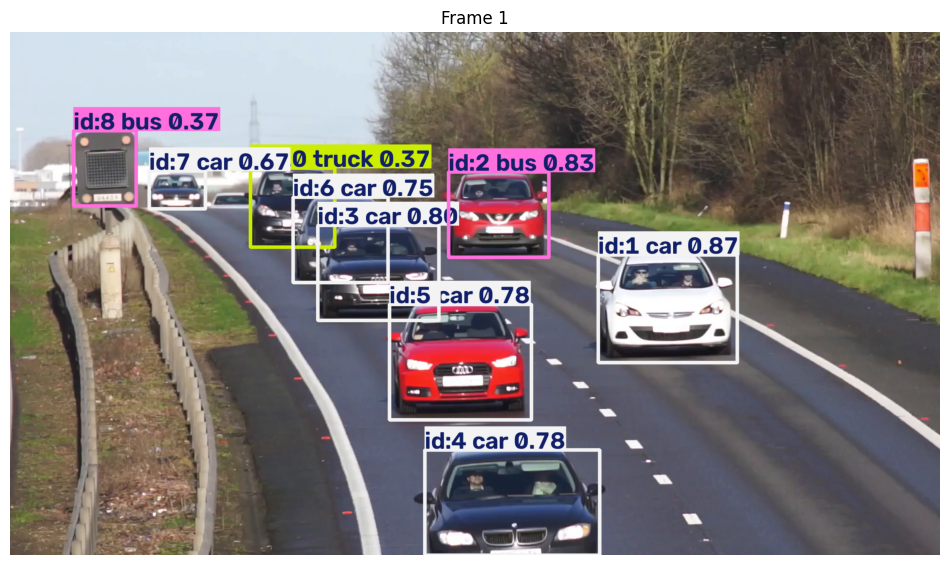

video 1/1 (frame 2/1501) /content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4: 384x640 7 cars, 1 bus, 16.1ms


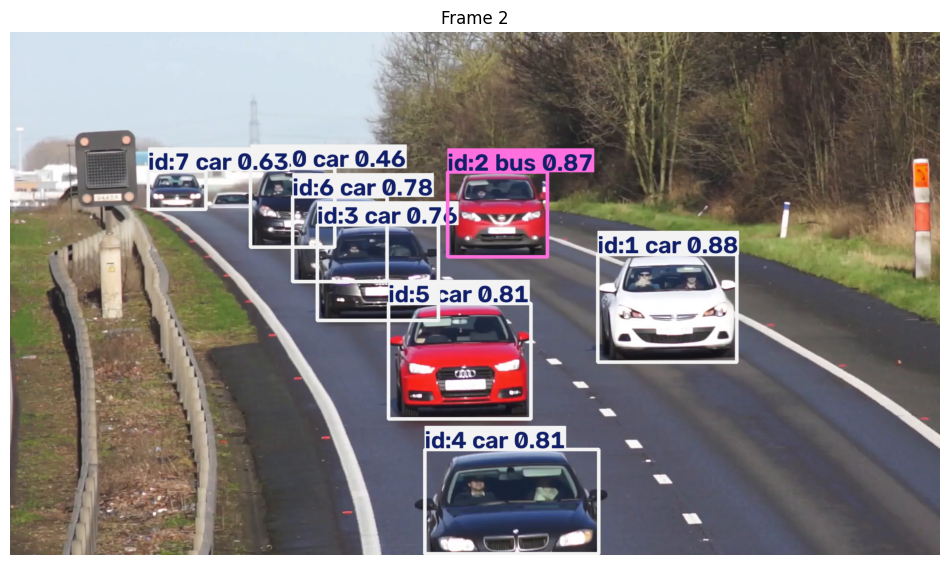

video 1/1 (frame 3/1501) /content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4: 384x640 7 cars, 1 bus, 24.0ms


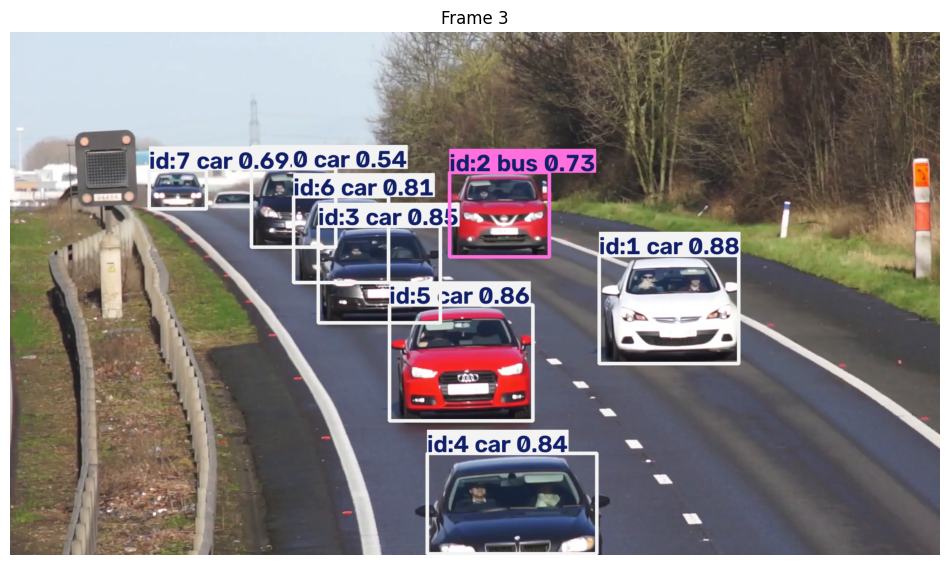

In [ ]:
results = model.track(
    source=video_path,
    classes=list(detector.VEHICLE_CLASSES.keys()),
    conf=0.35,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True
)

frame_count = 0

for r in results:
    annotated_frame = r.plot()

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Frame {frame_count + 1}")
    plt.show()

    frame_count += 1

    if frame_count >= 3:
        break

# Extract tracking data

In [ ]:
# Fresh call again — clean frame 0-99 window
results = model.track(
    source=video_path,
    classes=list(detector.VEHICLE_CLASSES.keys()),
    conf=0.35,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True
)

tracking_data = []
frame_count = 0

for r in results:
    if r.boxes.id is not None:
        for box, track_id in zip(r.boxes, r.boxes.id):
            track_id = int(track_id)
            class_id = int(box.cls[0])
            cls_name = detector.VEHICLE_CLASSES[class_id]

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            center_x = (x1 + x2) / 2
            center_y = (y1 + y2) / 2

            tracking_data.append({
                "frame": frame_count,
                "track_id": track_id,
                "class": cls_name,
                "center_x": center_x,
                "center_y": center_y
            })

    frame_count += 1
    if frame_count >= 100:
        break

print("Frames processed:", frame_count)
print("Tracking records:", len(tracking_data))

In [ ]:
# Check ID Stability
df = pd.DataFrame(tracking_data)
print("Unique track IDs:", df["track_id"].nunique())
print(df.head())

In [ ]:
# Plot one vehicle's trajectory — smooth line = stable tracking
one_track_id = df["track_id"].iloc[0]
one_track = df[df["track_id"] == one_track_id].sort_values("frame")

plt.plot(one_track["frame"], one_track["center_x"])
plt.xlabel("Frame")
plt.ylabel("center_x")
plt.title(f"Track ID {one_track_id} — X position over time")
plt.show()

# Save Annotated Output

In [ ]:
results = model.track(
    source=video_path,
    classes=list(detector.VEHICLE_CLASSES.keys()),
    conf=0.35,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True
)

cap_check = cv2.VideoCapture(video_path)
fps = cap_check.get(cv2.CAP_PROP_FPS)
w, h = int(cap_check.get(3)), int(cap_check.get(4))
cap_check.release()

out = cv2.VideoWriter("tracking_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

for r in results:
    out.write(r.plot())

out.release()
print("Saved tracking_output.mp4")

In [ ]:
from google.colab import files
files.download('tracking_output.mp4')